# Attestation timings after relaying within committee - full analysis for normal nodes

#### Maria Silva, August 2025


## 1. Imports

In [1]:
import os
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
data_dir = os.path.join(repo_dir, "data")

# Add src to path
sys.path.append(os.path.join(repo_dir, "src"))

In [4]:
from late_atts_model_runner import load_data

In [5]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Load data

In [6]:
df = load_data(data_dir, "sample_12243620_12294020")
df = df[df["header_from"]!="self_build"]
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 5263471 entries, 1060 to 10564738
Data columns (total 20 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   slot                          5263471 non-null  int64         
 1   atts_validator                5263471 non-null  int64         
 2   atts_subnet                   5263471 non-null  object        
 3   atts_arrival_time_ms          5263471 non-null  int64         
 4   request_datetime              4688856 non-null  datetime64[ns]
 5   publish_datetime              4688856 non-null  datetime64[ns]
 6   header_from                   5263471 non-null  object        
 7   publish_time_ms               5263471 non-null  float64       
 8   slot_start_datetime           5263471 non-null  datetime64[ns]
 9   request_time_ms               4688856 non-null  float64       
 10  p95_block_arrival_ms          5263471 non-null  int64         
 11 

## 3. Sample size / counts

In [6]:
print(df["slot"].nunique())
df["slot"].agg(["min", "max"])

4963


min    12243648
max    12293994
Name: slot, dtype: int64

In [7]:
df.groupby("header_from")["slot"].nunique().sort_values(ascending=False)/df["slot"].nunique()

header_from
ultrasound    0.803949
flashbots     0.109208
titan         0.086843
Name: slot, dtype: float64

In [8]:
df.groupby("entity").size().sort_values(ascending=False)/len(df)

entity
solo_stakers            8.658868e-02
binance                 8.404948e-02
coinbase                6.854374e-02
ether.fi                6.693568e-02
kiln                    4.306417e-02
                            ...     
csm_operator261_lido    5.699661e-07
csm_operator72_lido     3.799774e-07
csm_operator256_lido    3.799774e-07
csm_operator182_lido    3.799774e-07
csm_operator322_lido    3.799774e-07
Length: 743, dtype: float64

## 4. Distribution of attestation time since relay publish

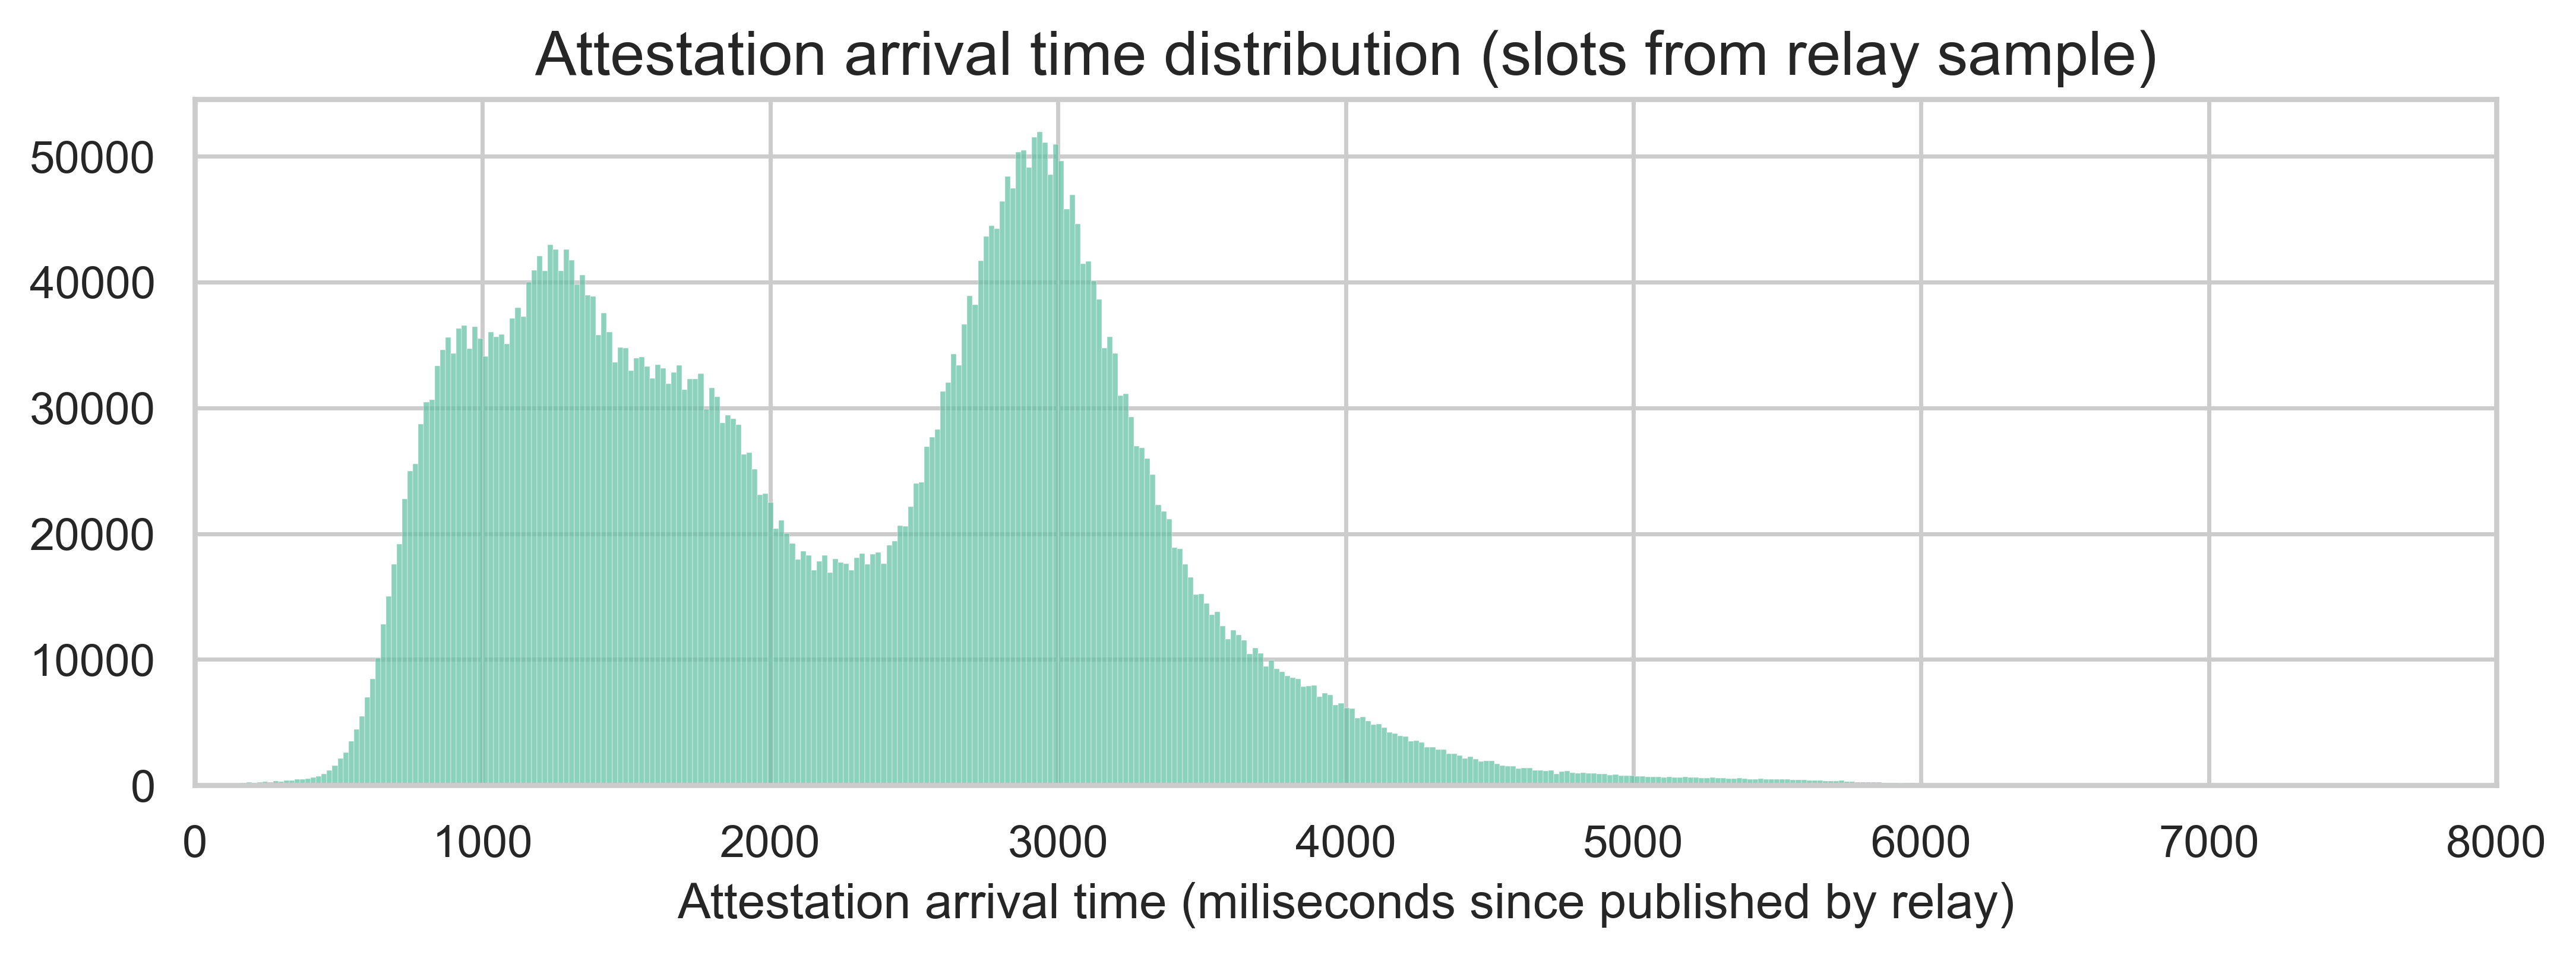

In [7]:
plt.figure(figsize=(10, 3))
sns.histplot(
    data=df,
    x="net_atts_arrival_time_ms"
)
plt.xlim(0,8000)
plt.title("Attestation arrival time distribution (slots from relay sample)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since published by relay)")
plt.show()

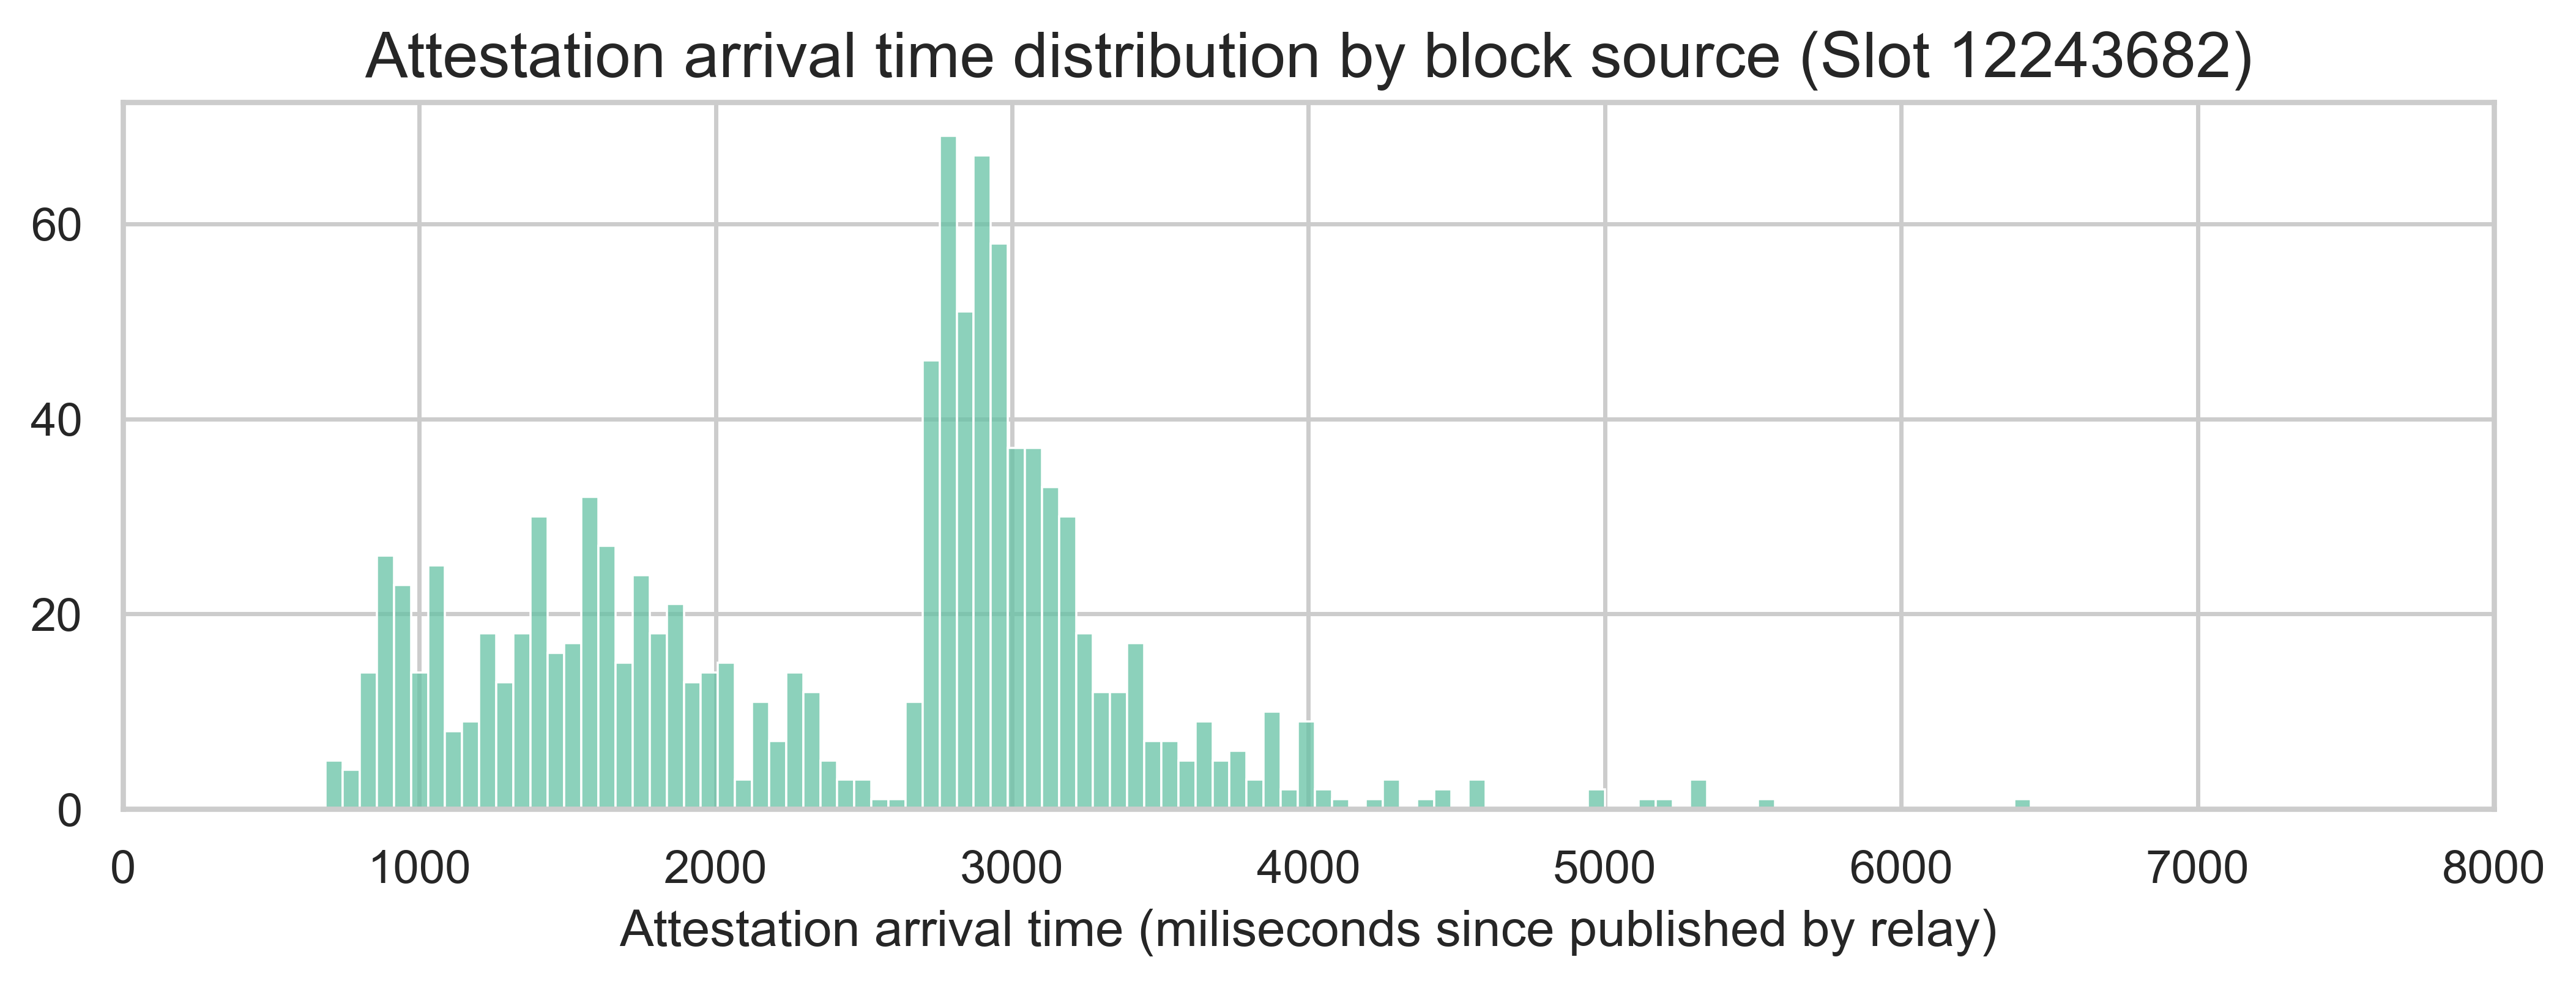

In [10]:
plt.figure(figsize=(10, 3))
sns.histplot(
    data=df[df["slot"]==12243682],
    x="net_atts_arrival_time_ms",
    bins=100
)
plt.xlim(0,8000)
plt.title("Attestation arrival time distribution by block source (Slot 12243682)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since published by relay)")
plt.show()

In [11]:
df.groupby("header_from")["net_atts_arrival_time_ms"].agg(["mean", "std"])

,mean,std
header_from,,
flashbots,2189.092619,1011.111251
titan,2109.086177,982.303250
ultrasound,2226.262442,975.831982


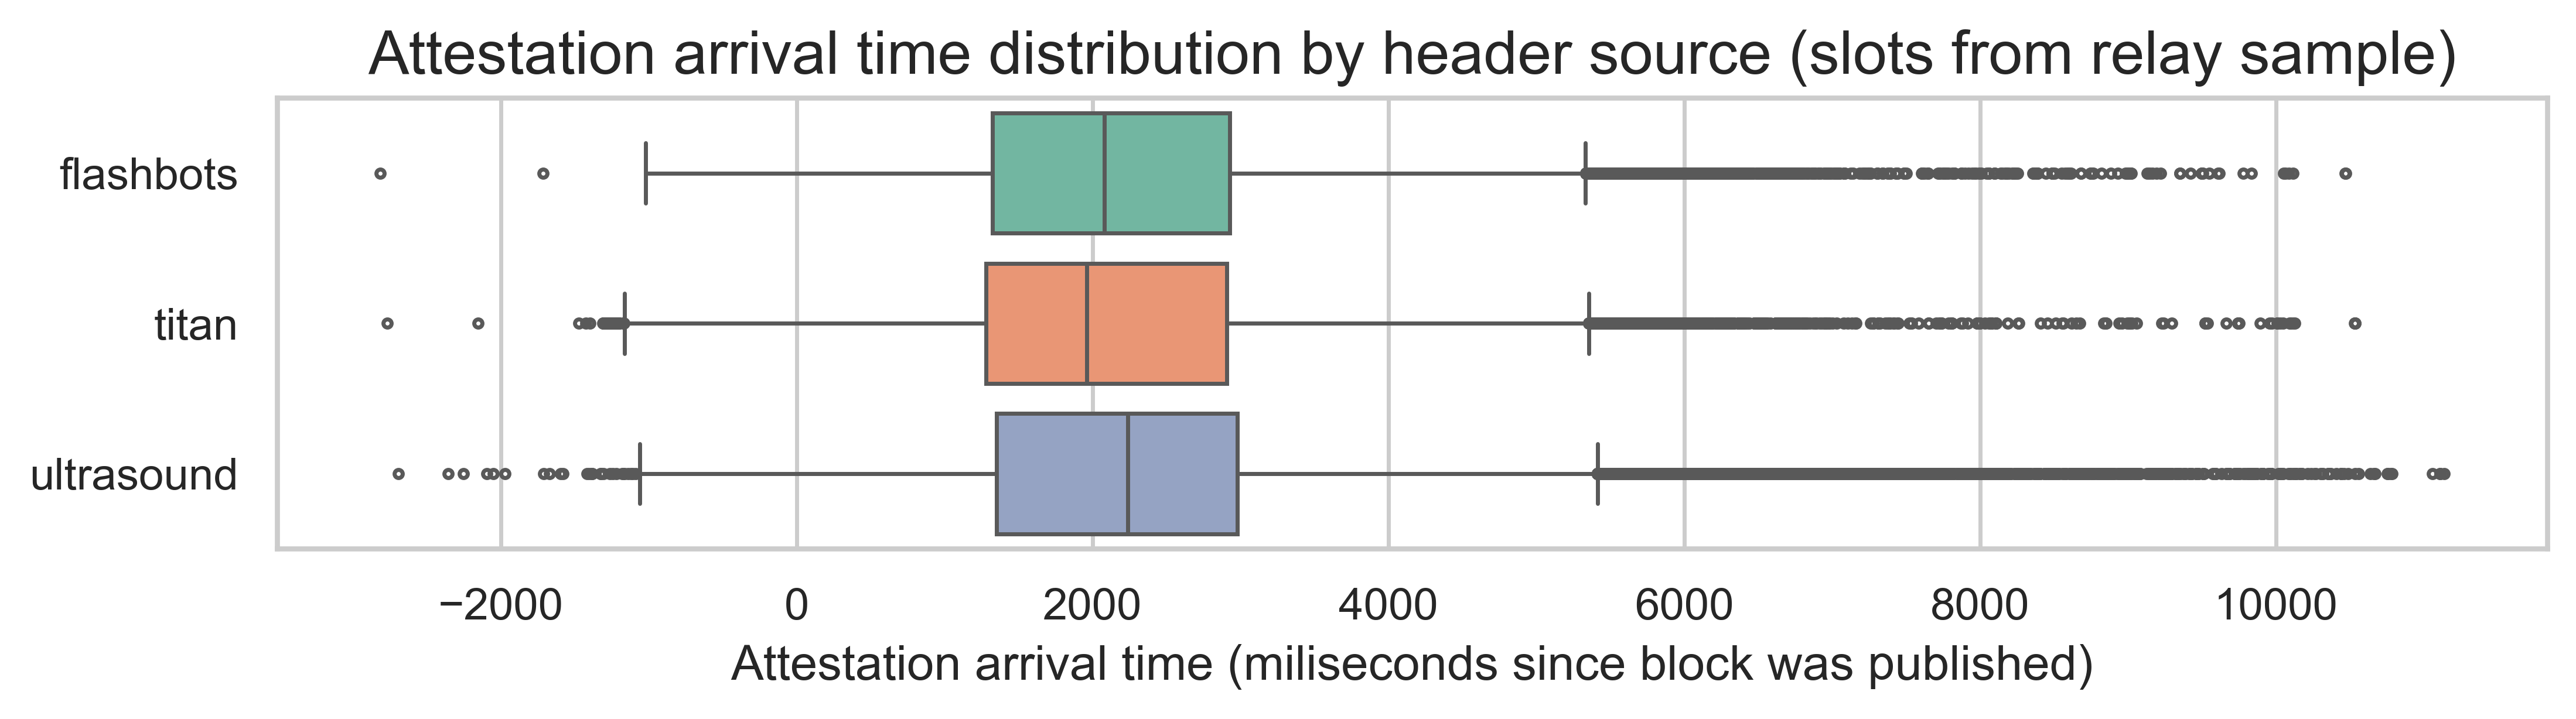

In [12]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=df.sort_values("header_from"),
    x="net_atts_arrival_time_ms",
    y="header_from",
    hue="header_from",
    legend=False,
    fliersize=2
)
plt.title("Attestation arrival time distribution by header source (slots from relay sample)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since block was published)")
plt.show()

In [13]:
df.groupby("header_from")["net_atts_arrival_time_ms"].quantile(0.95)

header_from
flashbots     3855.000000
titan         3642.357317
ultrasound    3734.000000
Name: net_atts_arrival_time_ms, dtype: float64

## 5. Attestation arrivals by entity

In [14]:
entity_counts = df["entity"].value_counts()/len(df)
ent_df = df.merge(entity_counts, left_on="entity", right_index=True)
ent_df["entity"] = np.where(ent_df["count"]>0.01, ent_df["entity"], "other")
median_df = (
    ent_df.groupby("entity")["net_atts_arrival_time_ms"]
    .median()
    .reset_index()
    .rename(columns={"net_atts_arrival_time_ms": "median"})
)
ent_df = ent_df.merge(median_df, on="entity", how="left").sort_values("median")

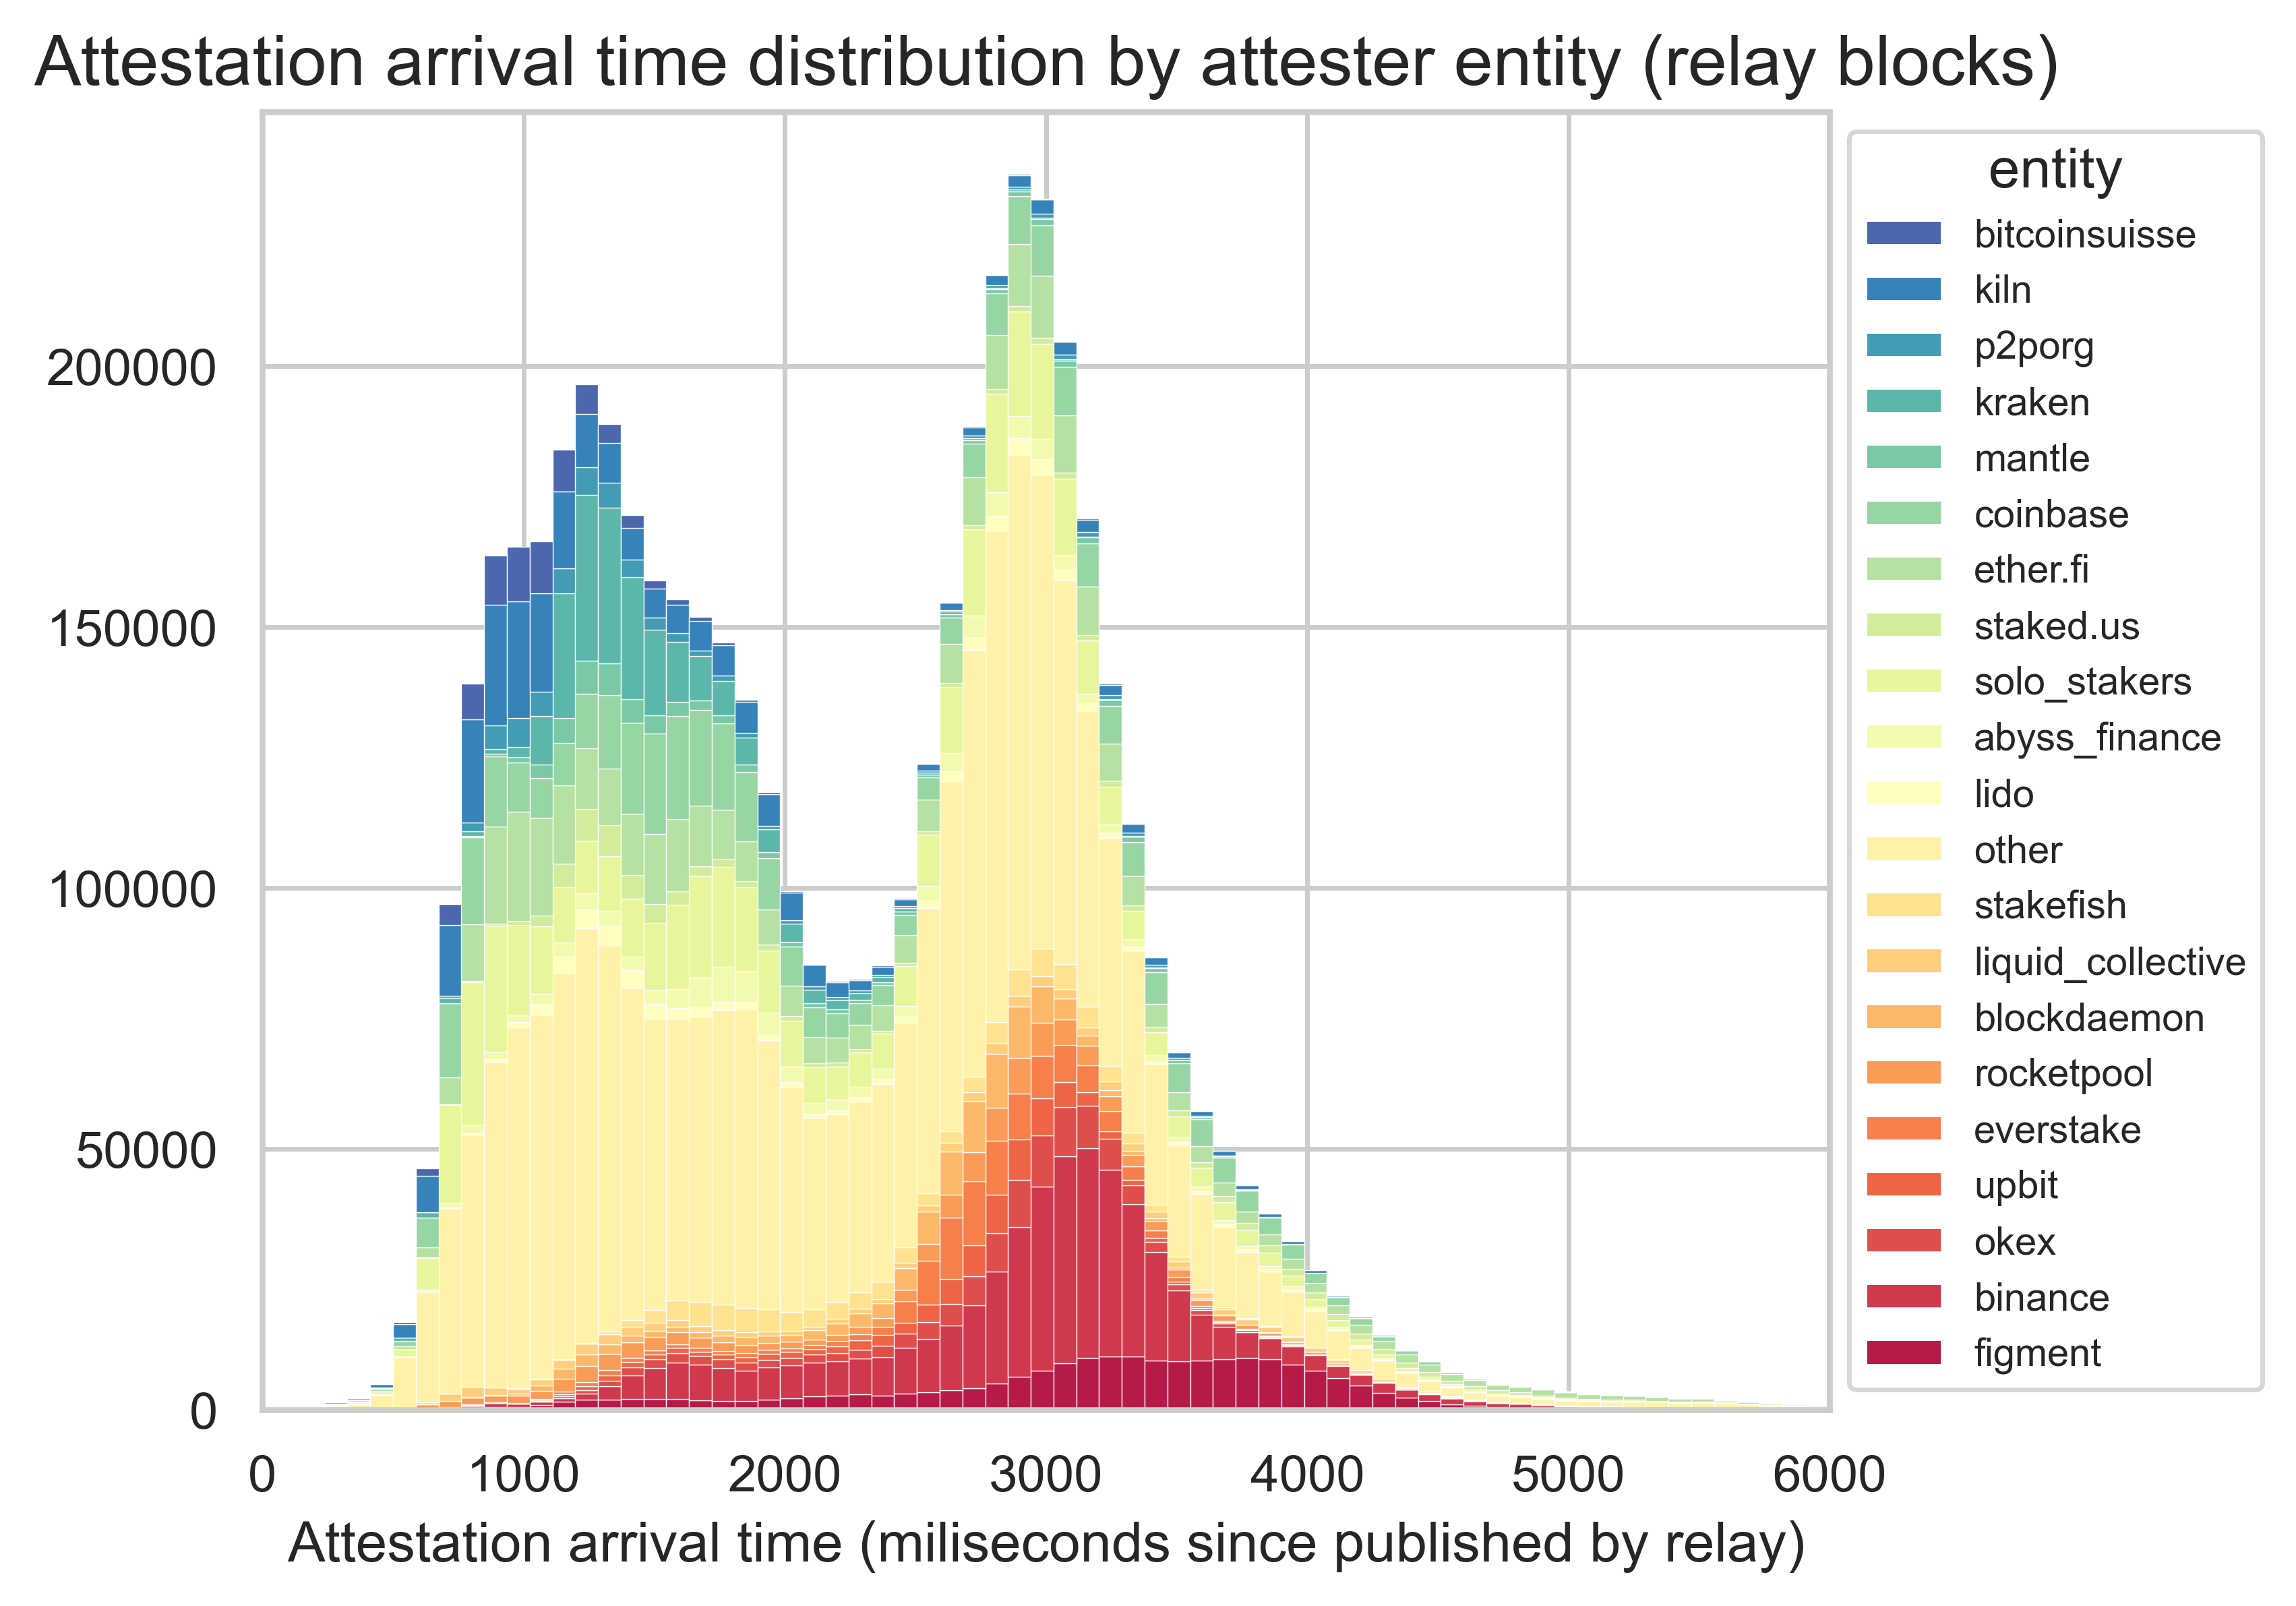

In [26]:
plt.figure(figsize=(6, 5))
ax = sns.histplot(
    data=ent_df,
    x="net_atts_arrival_time_ms",
    hue="entity",
    multiple="stack",
    palette="Spectral_r",
    alpha=1,
    bins=160
)
plt.xlim(0,6000)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize='x-small')
plt.title("Attestation arrival time distribution by attester entity (relay blocks)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since published by relay)")
plt.show()

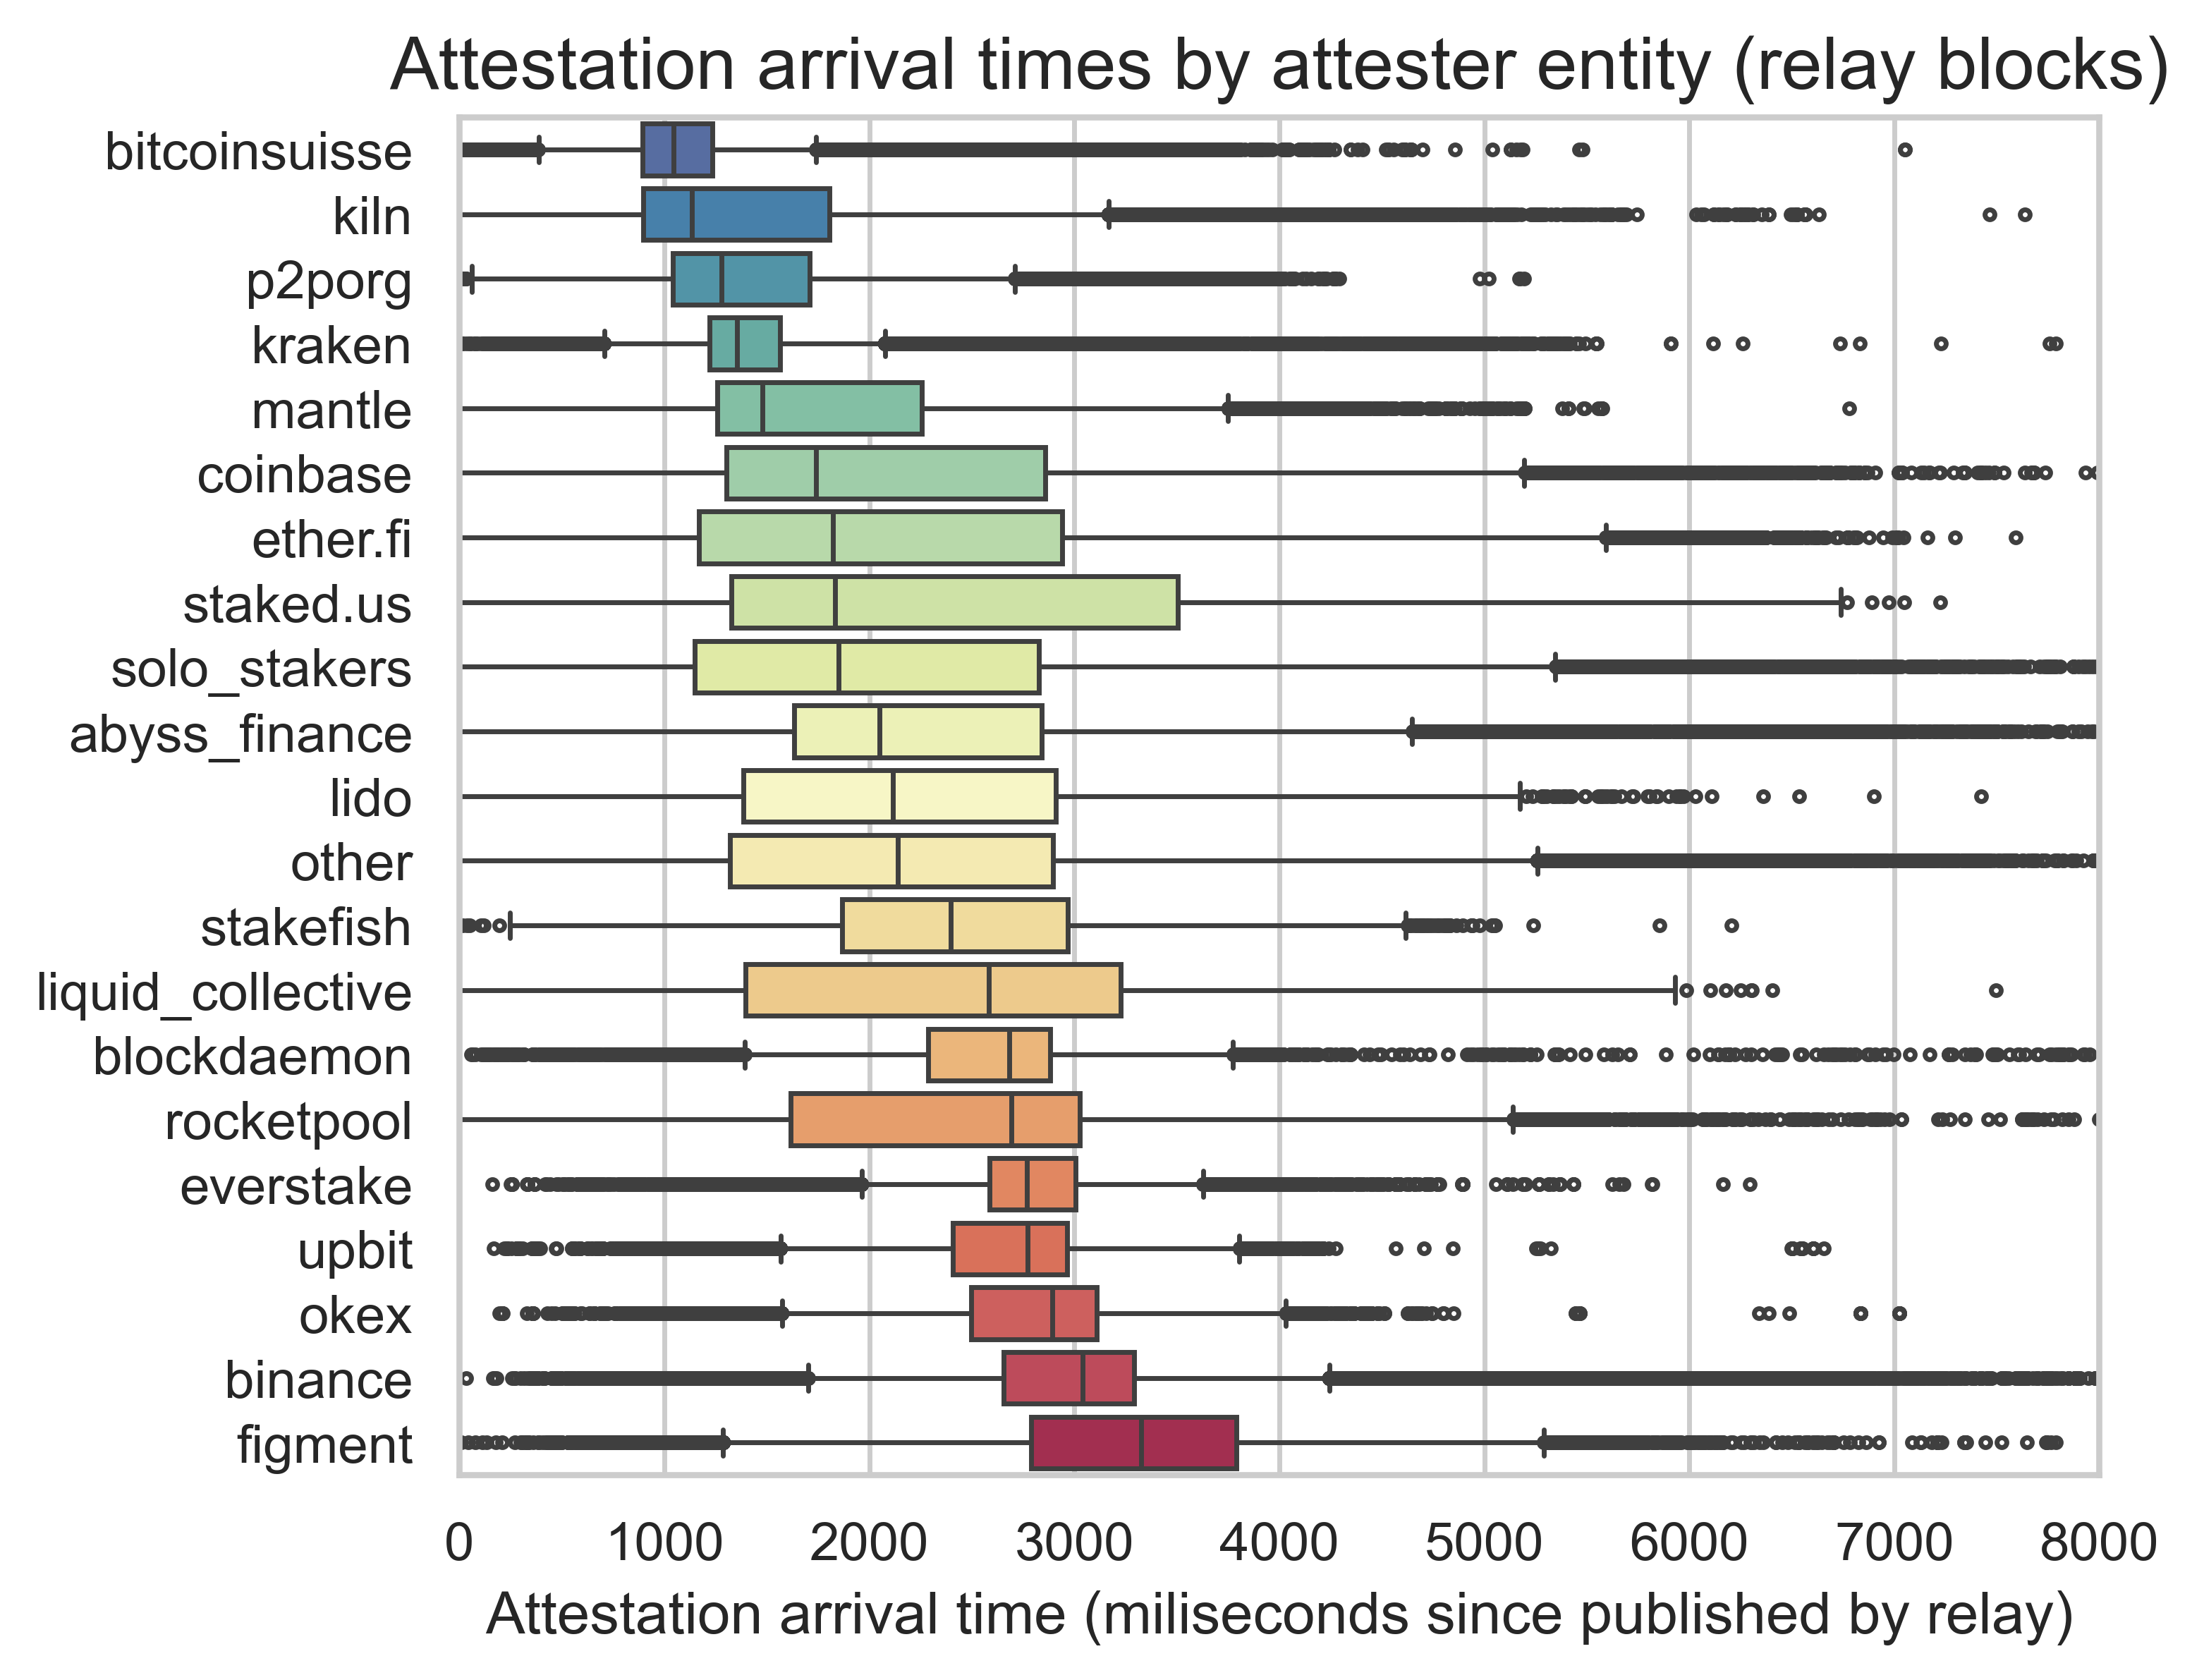

In [25]:
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=ent_df,
    x="net_atts_arrival_time_ms",
    y="entity",
    hue="entity",
    palette="Spectral_r",
    legend=False,
    fliersize=2
)
plt.xlim(0,8000)
plt.title("Attestation arrival times by attester entity (relay blocks)")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since published by relay)")
plt.show()

## 6. Super-majority attestations (65%)

In [17]:
p66_df = (
    df.groupby(["slot", "header_from", "atts_subnet"])["net_atts_arrival_time_ms"]
    .quantile(0.66)
    .reset_index()
)

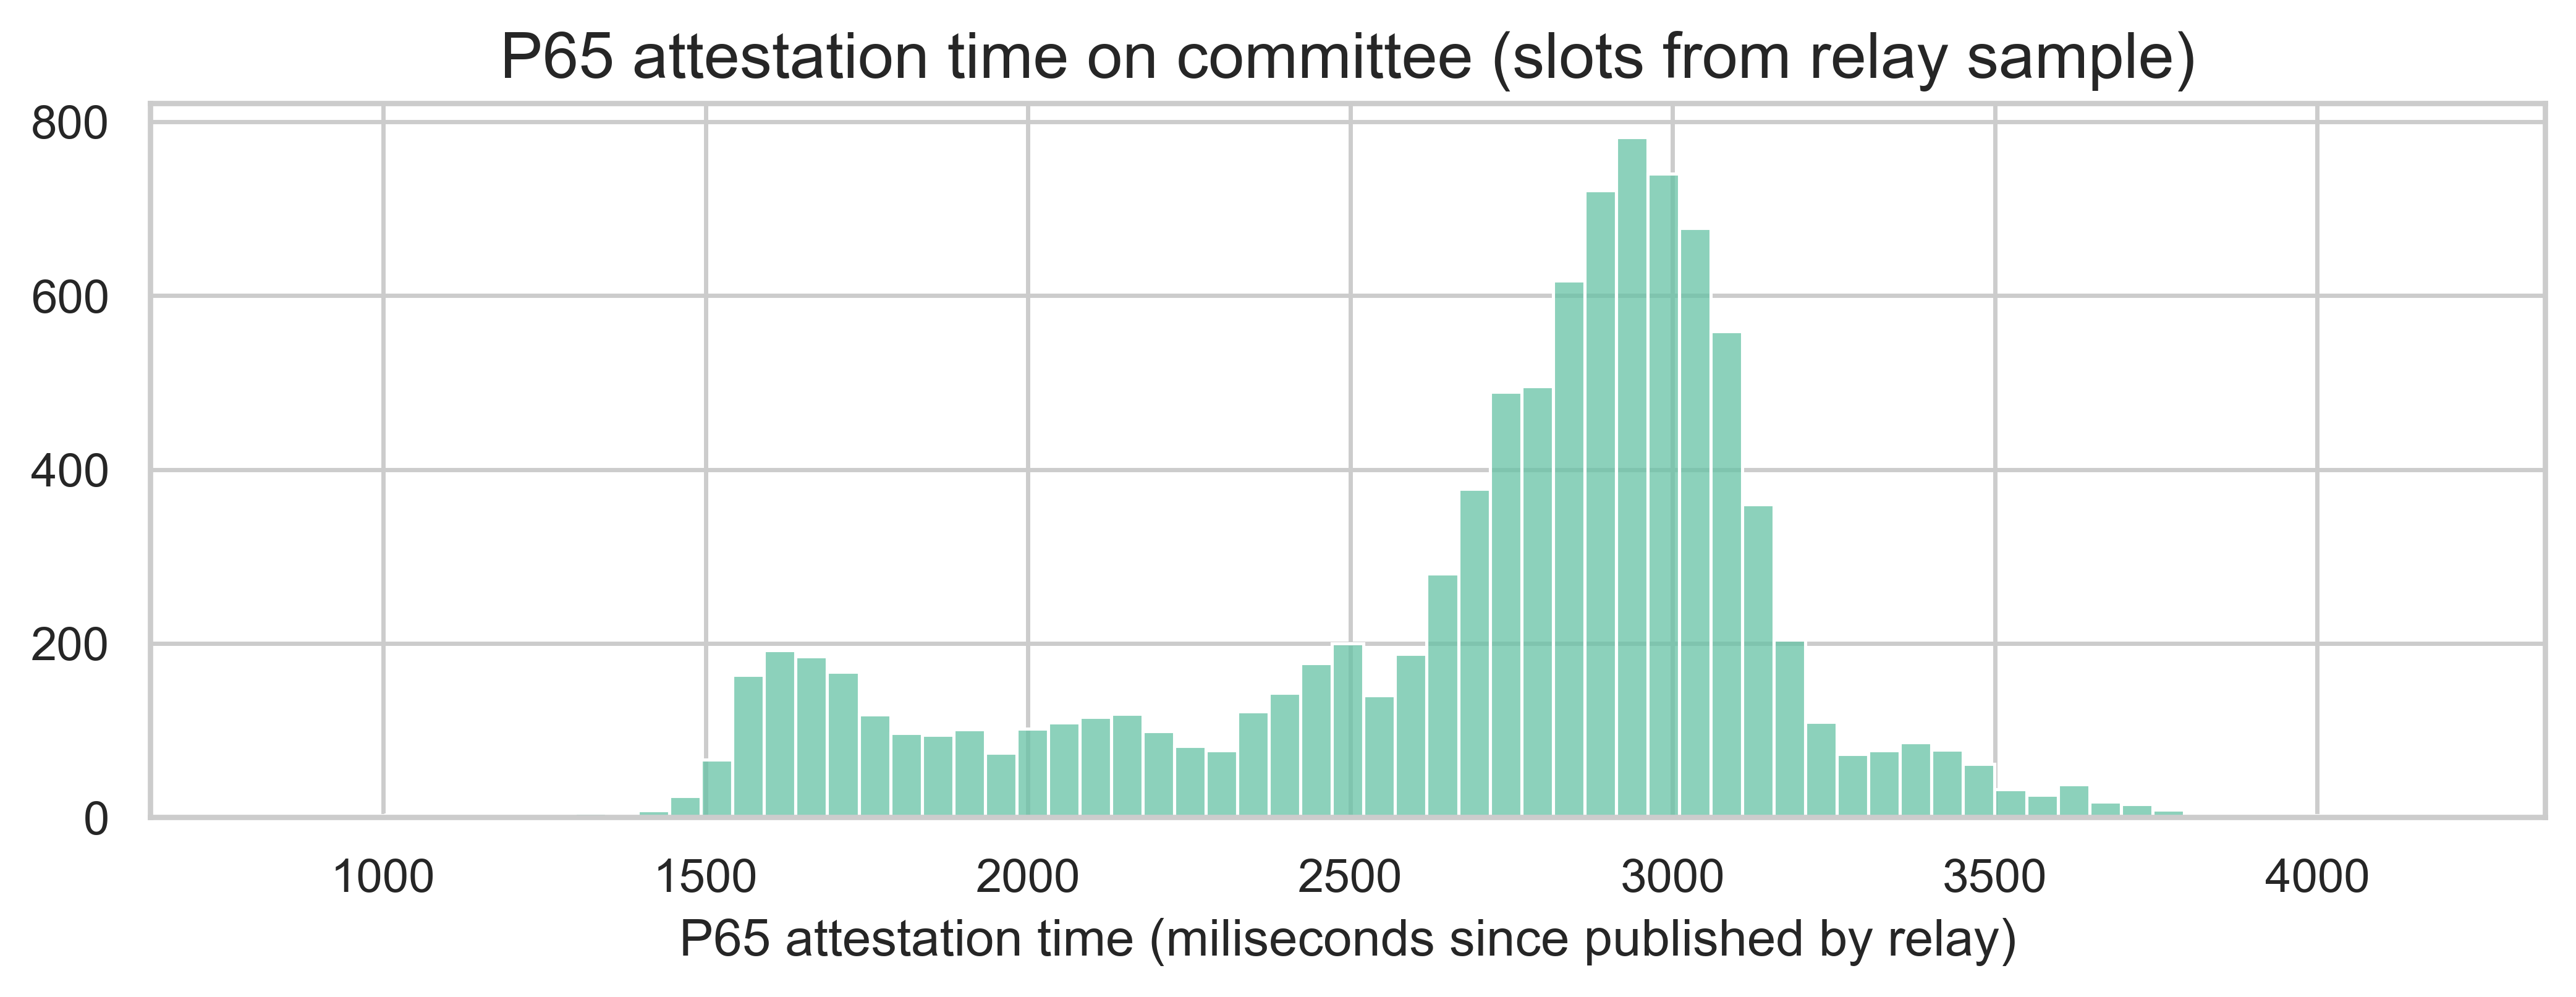

In [18]:
plt.figure(figsize=(10, 3))
sns.histplot(
    data=p66_df,
    x="net_atts_arrival_time_ms"
)

plt.title("P65 attestation time on committee (slots from relay sample)")
plt.ylabel("")
plt.xlabel("P65 attestation time (miliseconds since published by relay)")
plt.show()

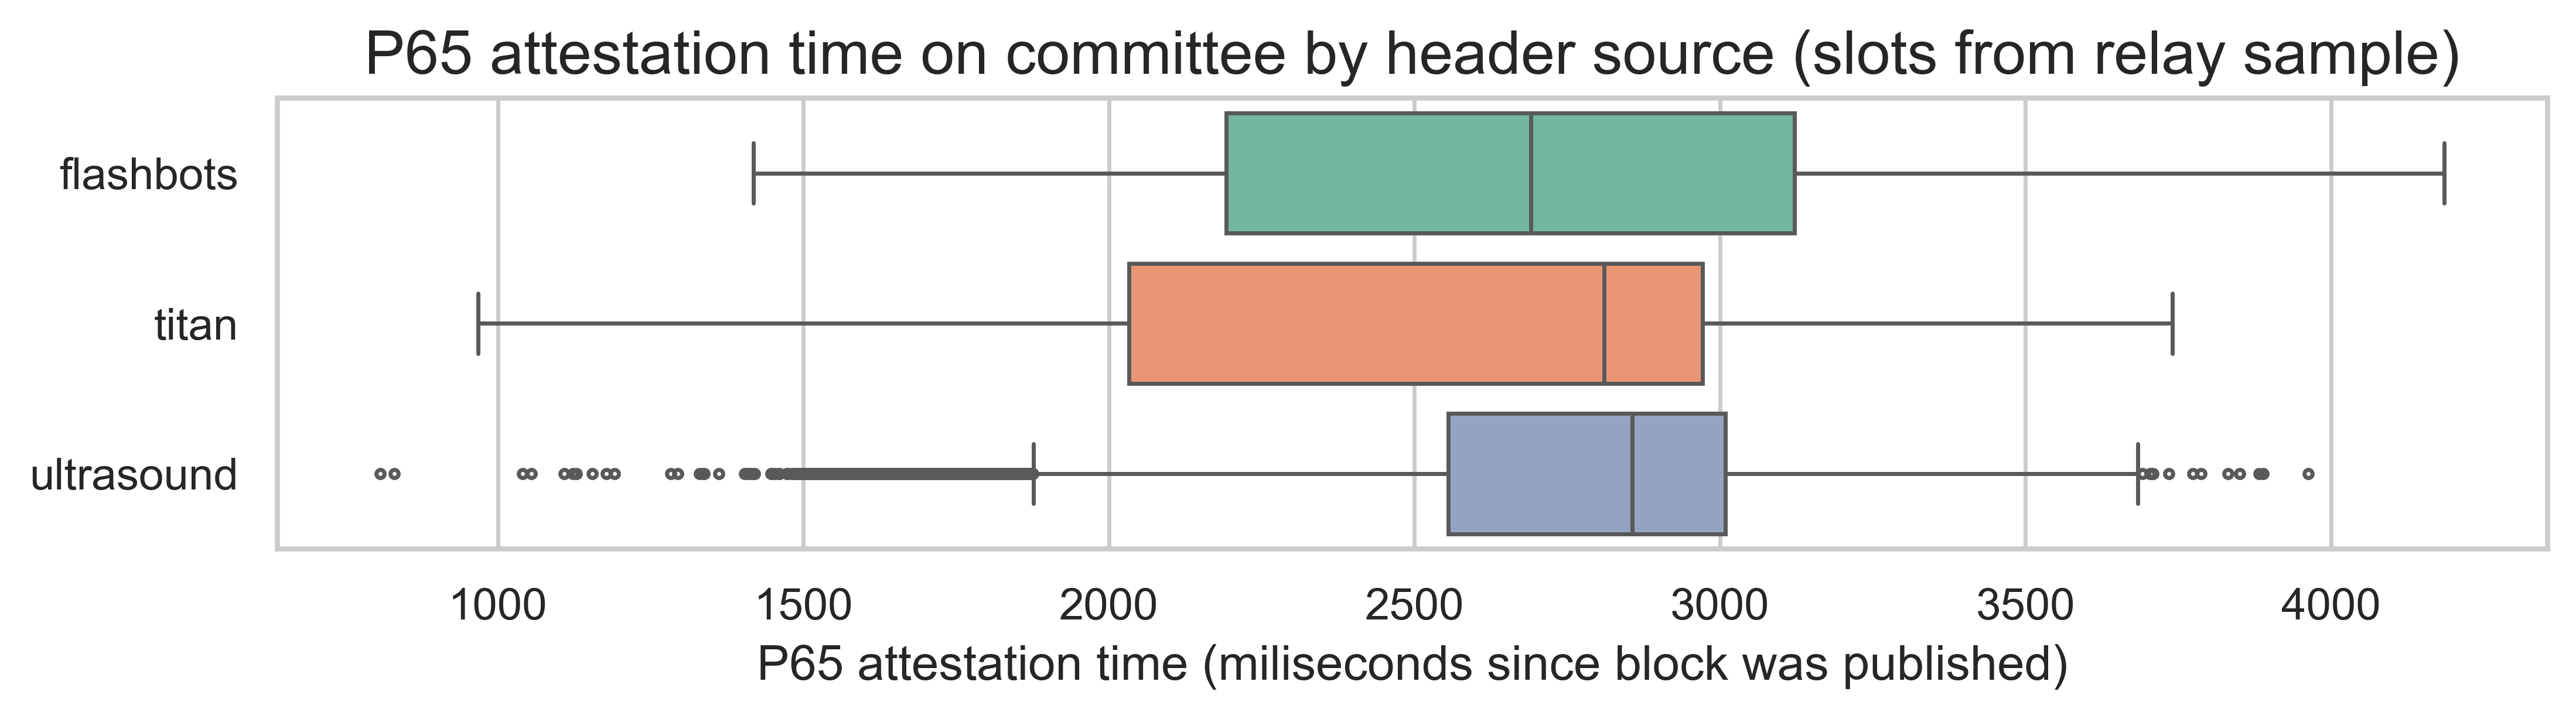

In [19]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=p66_df.sort_values("header_from"),
    x="net_atts_arrival_time_ms",
    y="header_from",
    hue="header_from",
    legend=False,
    fliersize=2
)
plt.title("P65 attestation time on committee by header source (slots from relay sample)")
plt.ylabel("")
plt.xlabel("P65 attestation time (miliseconds since block was published)")
plt.show()

In [20]:
p66_df["net_atts_arrival_time_ms"].quantile([0.5, 0.8, 0.9, 0.95, 0.99])

0.50    2844.000
0.80    3043.140
0.90    3134.130
0.95    3271.495
0.99    3582.740
Name: net_atts_arrival_time_ms, dtype: float64

## 7. P95 attestations

In [21]:
p95_df = (
    df.groupby(["slot", "header_from", "atts_subnet"])["net_atts_arrival_time_ms"]
    .quantile(0.95)
    .reset_index()
)

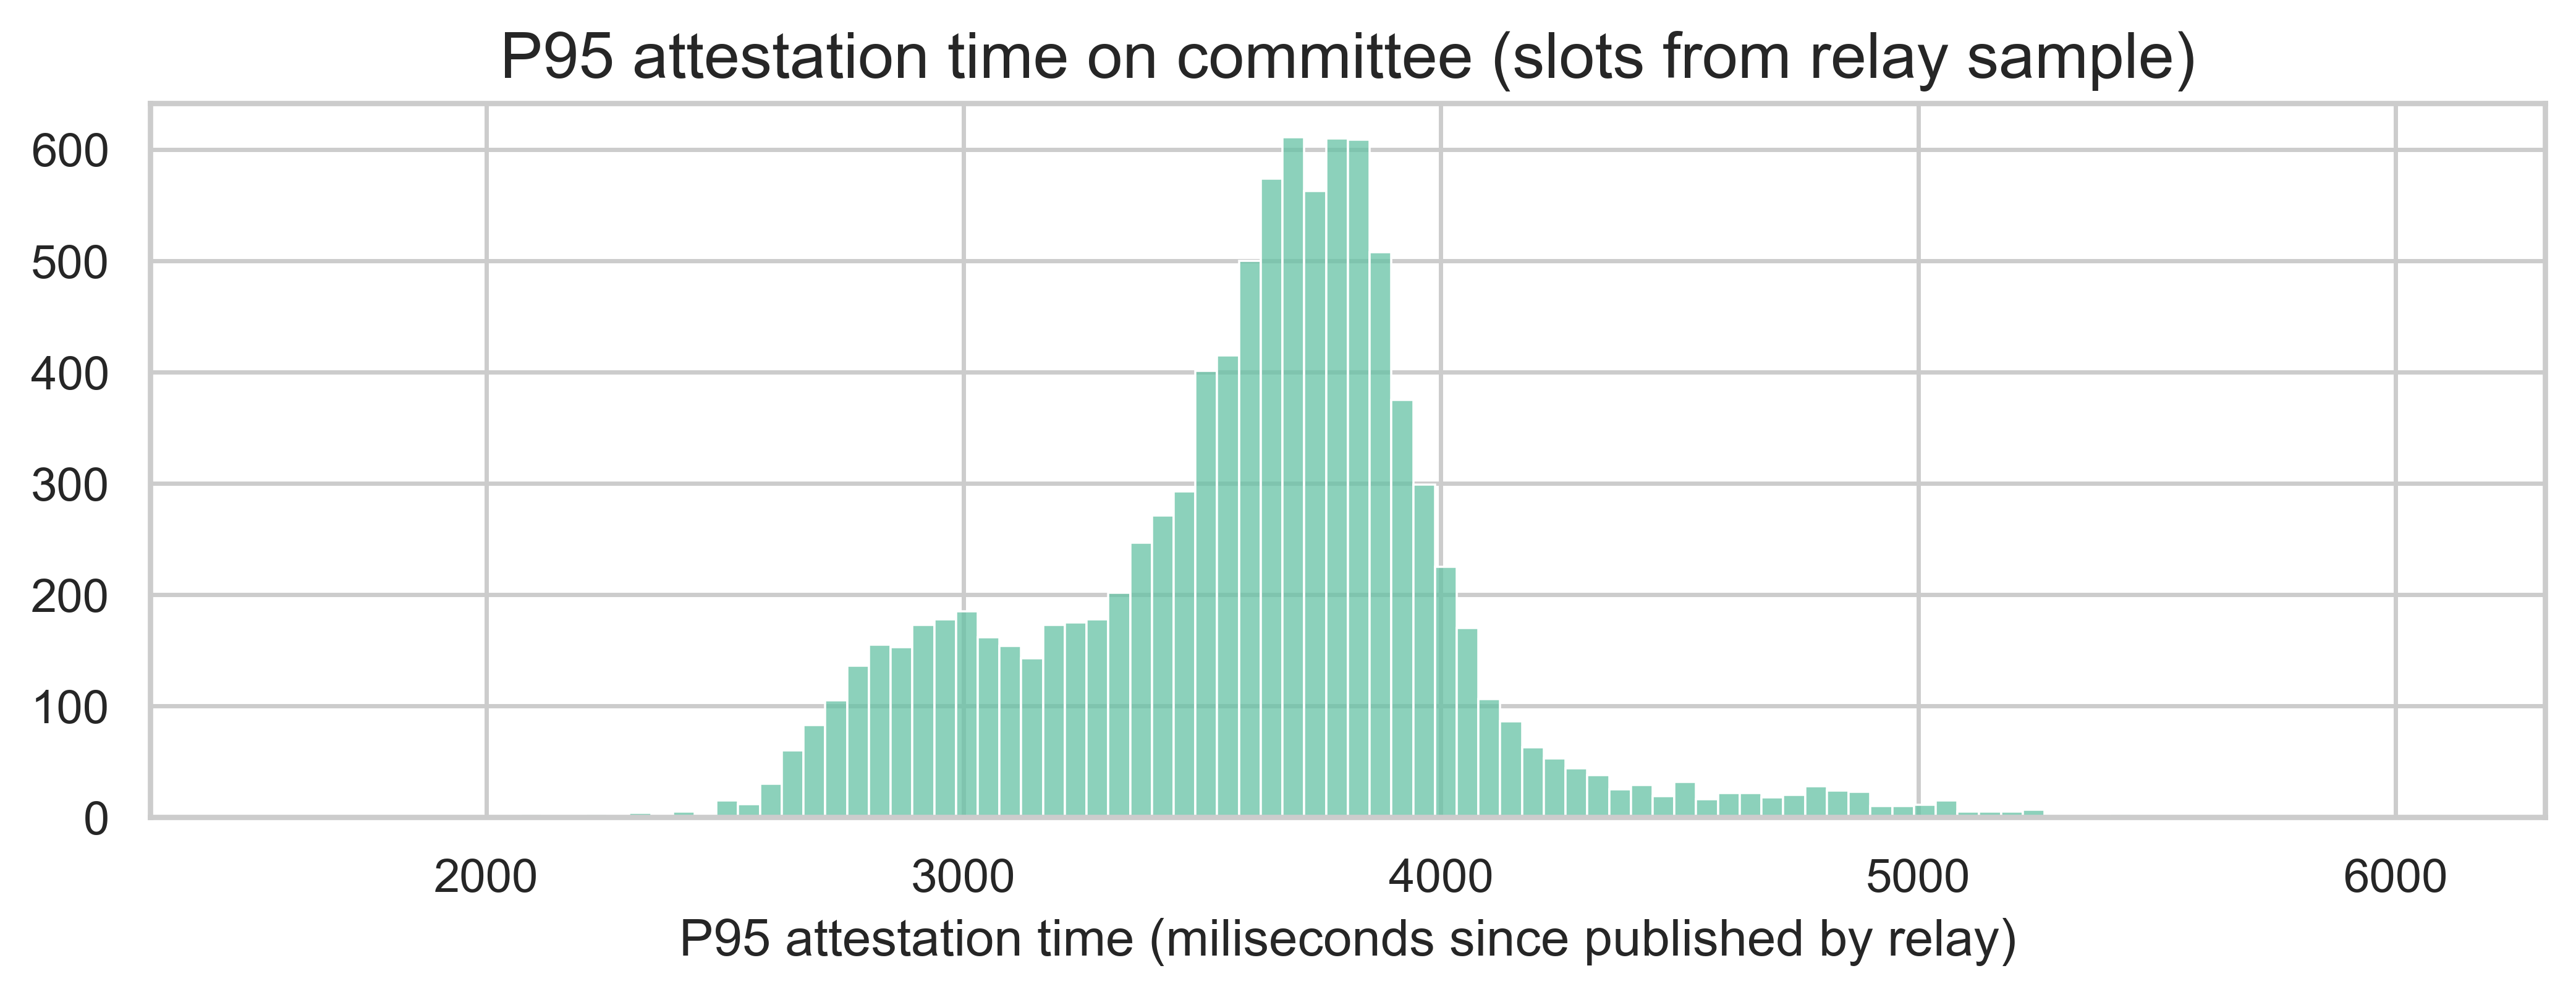

In [22]:
plt.figure(figsize=(10, 3))
sns.histplot(
    data=p95_df,
    x="net_atts_arrival_time_ms"
)

plt.title("P95 attestation time on committee (slots from relay sample)")
plt.ylabel("")
plt.xlabel("P95 attestation time (miliseconds since published by relay)")
plt.show()

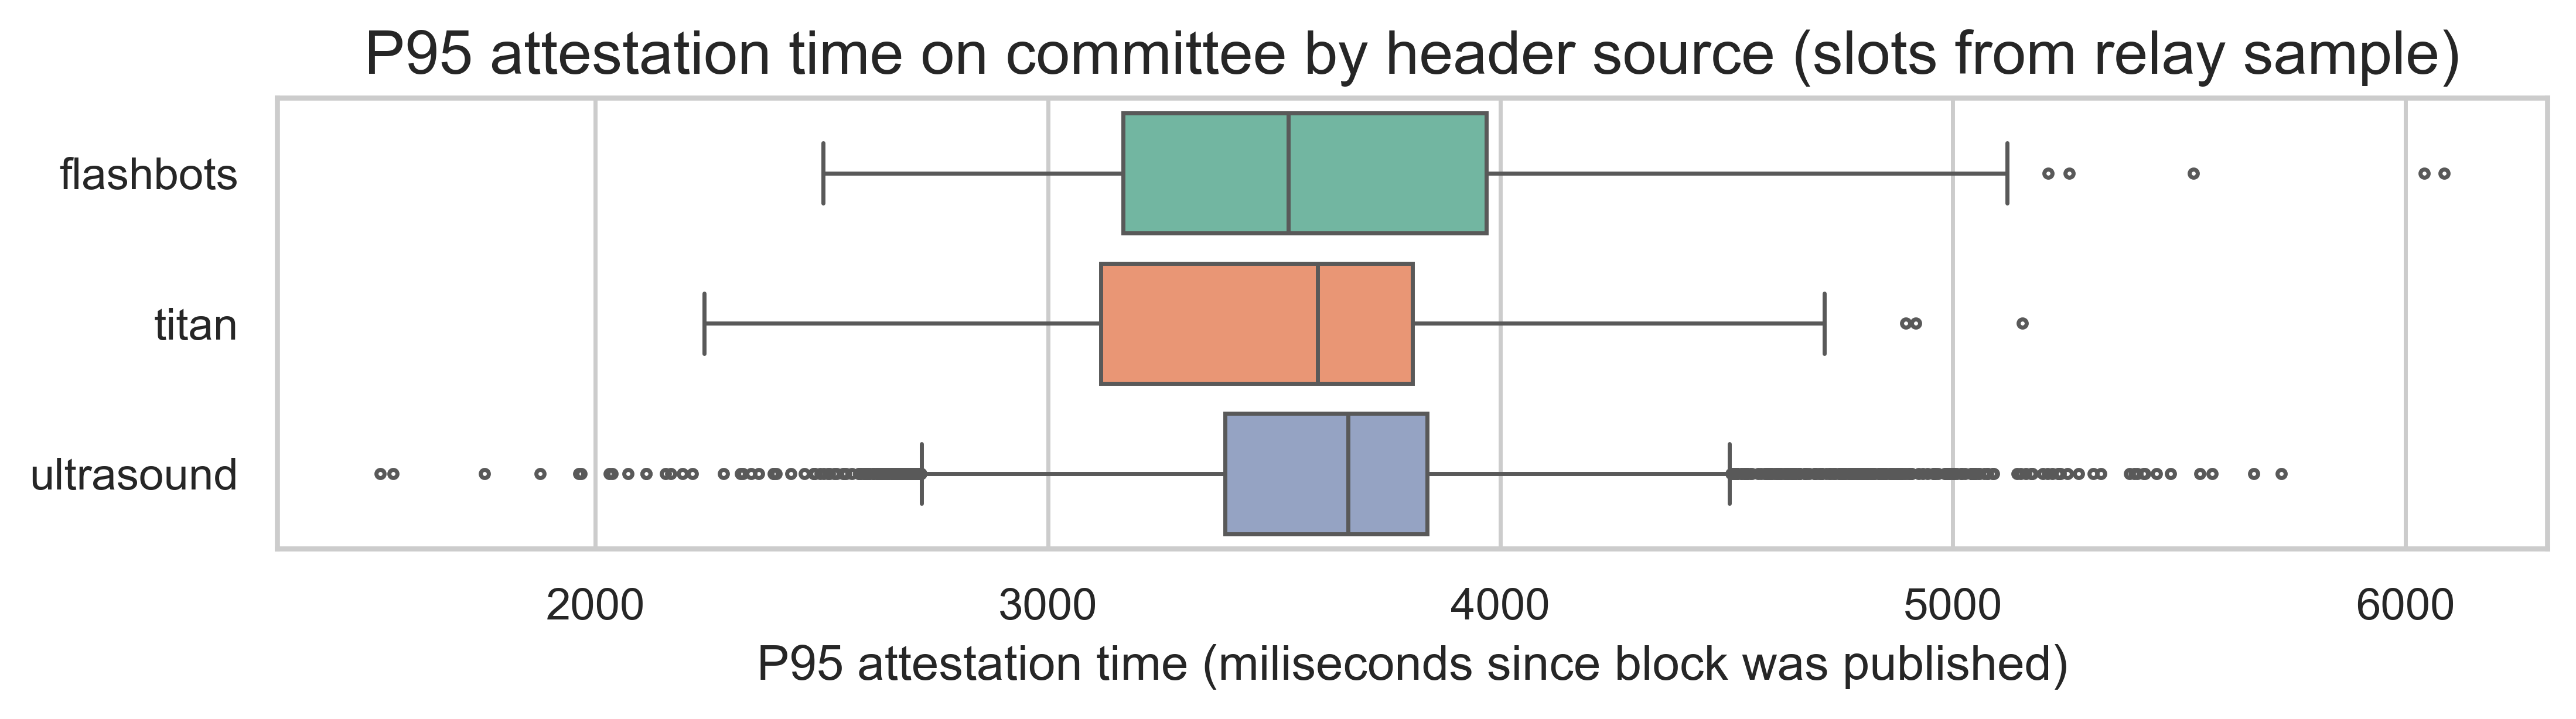

In [23]:
plt.figure(figsize=(10, 2))
sns.boxplot(
    data=p95_df.sort_values("header_from"),
    x="net_atts_arrival_time_ms",
    y="header_from",
    hue="header_from",
    legend=False,
    fliersize=2
)
plt.title("P95 attestation time on committee by header source (slots from relay sample)")
plt.ylabel("")
plt.xlabel("P95 attestation time (miliseconds since block was published)")
plt.show()

In [24]:
p95_df["net_atts_arrival_time_ms"].quantile([0.5, 0.8, 0.9, 0.95, 0.99])

0.50    3650.0000
0.80    3881.1500
0.90    4017.2750
0.95    4216.6875
0.99    4869.3500
Name: net_atts_arrival_time_ms, dtype: float64

In [27]:
p95_df["net_atts_arrival_time_ms"].agg(["mean", "std"])

mean    3589.683776
std      443.061280
Name: net_atts_arrival_time_ms, dtype: float64